# 05. Model Explainability with SHAP (SHapley Additive exPlanations)

## Overview
In this notebook, we apply SHAP to interpret the predictions of our best-performing churn model.

### Key Analysis Components:
1. **Methodological & Epistemological Disclaimer**: Explicitly document that SHAP values quantify feature contributions to *model predictions post-hoc* and do *not* establish direct causal relationships.
2. **Global Feature Importance**: Bar plots and Beeswarm summary plots illustrating overall feature drivers across the test cohort.
3. **Local Customer Explanations**: Individual customer force plots for top high-risk churners.
4. **Retention Actionability**: Extracting high-impact drivers for customer retention intervention.


NOTE:
 **Methodological Disclaimer on SHAP Interpretability vs. Causality**
 
 - **Post-Hoc Model Explanation**: SHAP (SHapley Additive exPlanations) measures how much each feature contributes to pushing the model's output above or below the baseline expected value.
 - **Correlation vs. Causation**: High SHAP importance indicates strong association and predictive utility within the model's learned function. It **does not prove a causal mechanism** (e.g., offering a discount or changing internet type will not automatically alter customer intent unless validated via causal inference or randomized A/B testing).


### Library Imports and Setup
We import `shap`, `joblib`, `matplotlib`, `pandas`, and path management tools.

In [3]:
# Library Imports and Setup

import sys
import json
import warnings

# Suppress the specific tqdm Jupyter widget warning BEFORE importing SHAP
warnings.filterwarnings(
    "ignore",
    message=r"IProgress not found.*",
    category=Warning
)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap


# Set project root path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
SHAP_DIR = PROJECT_ROOT / "outputs" / "shap"

SHAP_DIR.mkdir(parents=True, exist_ok=True)

# Enable SHAP JS in notebooks
shap.initjs()

### Load Model Pipeline and Test Data
We load `X_train.csv`, `X_test.csv`, `y_test.csv`, and the saved best model pipeline artifact `models/best_model.joblib`.

In [4]:
best_bundle = joblib.load(MODEL_DIR / "best_model.joblib")
pipeline = best_bundle['model']
threshold = best_bundle['threshold']
candidate_name = best_bundle['name']

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns").astype(int)
test_ids = pd.read_csv(DATA_DIR / "test_ids_target.csv")['CustomerID']

print(f"Model Pipeline Loaded: {candidate_name}")
print(f"Decision Threshold: {threshold:.4f}")


Model Pipeline Loaded: LogisticRegression__none
Decision Threshold: 0.3005


### Extract Preprocessed Feature Matrix and Names
SHAP calculates feature contributions on the transformed numeric space output by our `ColumnTransformer` preprocessor.

In [5]:
preprocessor = pipeline.named_steps['preprocess']
estimator = pipeline.named_steps['model']

# Transform background training sample (for baseline value) and test features
X_train_transformed = preprocessor.transform(X_train.head(250))
X_test_transformed = preprocessor.transform(X_test)

feature_names = list(preprocessor.get_feature_names_out())
# Clean feature names for clean plotting
clean_feature_names = [col.replace('num__', '').replace('cat__', '') for col in feature_names]

print(f"Transformed Features Count: {len(clean_feature_names)}")


Transformed Features Count: 57


### Compute SHAP Values
We initialize the appropriate SHAP Explainer (`TreeExplainer` for tree models like XGBoost/RandomForest, `LinearExplainer` / `Explainer` for Logistic Regression) and calculate SHAP values on transformed test features.

In [6]:
# Compute SHAP values on transformed test set
try:
    explainer = shap.Explainer(estimator, X_train_transformed, feature_names=clean_feature_names)
    shap_explanation = explainer(X_test_transformed)
except Exception as e:
    print("Falling back to TreeExplainer:", e)
    explainer = shap.TreeExplainer(estimator, feature_names=clean_feature_names)
    shap_explanation = explainer(X_test_transformed)

# Handle multi-class output if applicable (extract positive churn class index 1)
if len(shap_explanation.shape) == 3:
    shap_values = shap_explanation.values[:, :, 1]
    base_value = shap_explanation.base_values[0, 1] if hasattr(shap_explanation.base_values, '__len__') else shap_explanation.base_values
else:
    shap_values = shap_explanation.values
    base_value = shap_explanation.base_values[0] if hasattr(shap_explanation.base_values, '__len__') else shap_explanation.base_values

print(f"SHAP Values Matrix Shape: {shap_values.shape}")
print(f"Base Value (Expected log-odds or prob): {base_value:.4f}")

# Save SHAP matrix
pd.DataFrame(shap_values, columns=clean_feature_names).to_csv(SHAP_DIR / "shap_values.csv", index=False)


SHAP Values Matrix Shape: (1409, 57)
Base Value (Expected log-odds or prob): -1.8585


### Global Feature Importance (Bar Plot & Beeswarm Plot)
The Bar Plot ranks features by mean absolute SHAP value, while the Beeswarm Plot reveals how high vs low feature values push predicted churn probabilities up or down.

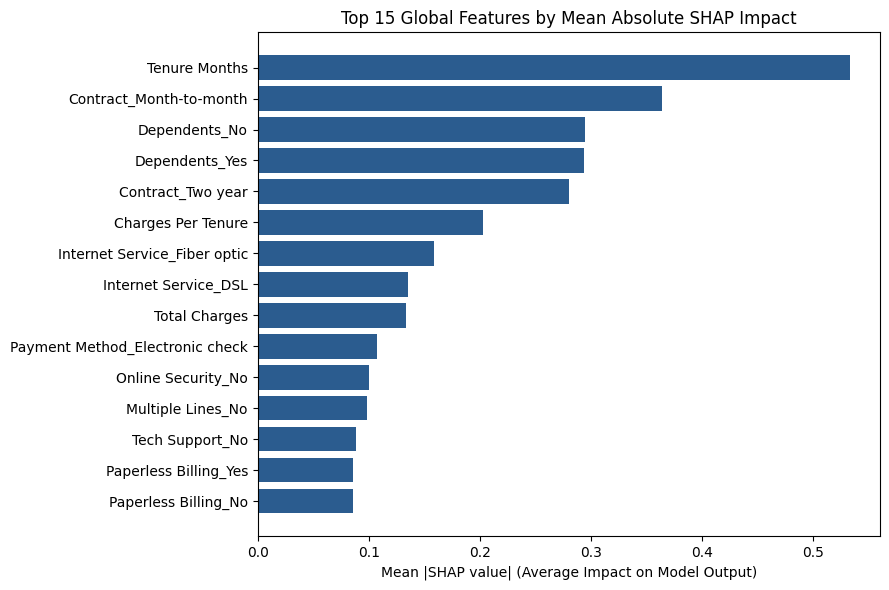

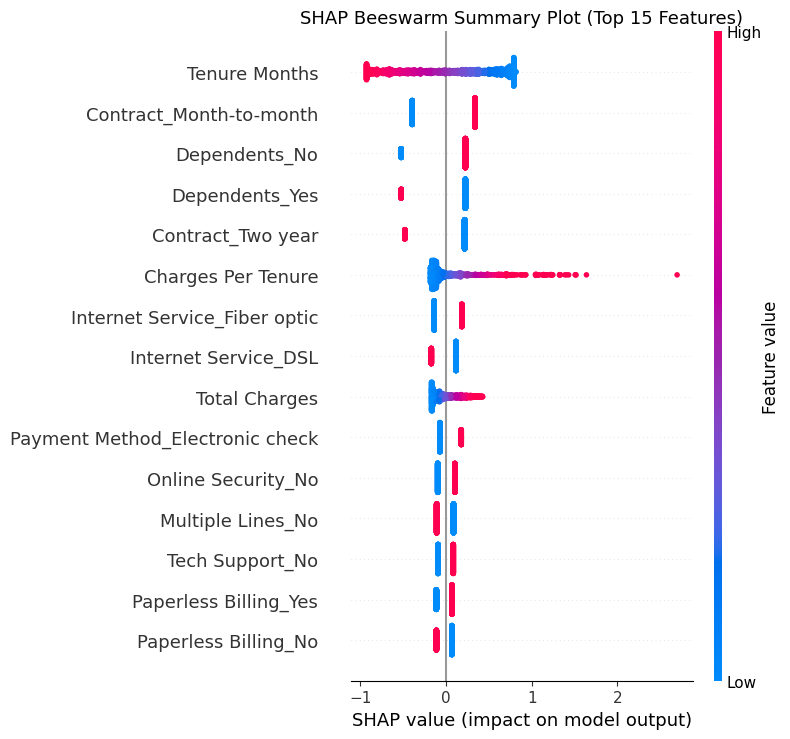

In [7]:
mean_abs_shap = pd.DataFrame({
    'feature': clean_feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_abs_shap.to_csv(SHAP_DIR / "shap_global_importance.csv", index=False)

# Bar Plot
plt.figure(figsize=(9, 6))
plt.barh(mean_abs_shap['feature'].head(15)[::-1], mean_abs_shap['mean_abs_shap'].head(15)[::-1], color='#2b5c8f')
plt.title("Top 15 Global Features by Mean Absolute SHAP Impact")
plt.xlabel("Mean |SHAP value| (Average Impact on Model Output)")
plt.tight_layout()
plt.savefig(SHAP_DIR / "shap_importance_bar.png", dpi=150)
plt.show()

# Beeswarm Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_transformed, feature_names=clean_feature_names, max_display=15, show=False)
plt.title("SHAP Beeswarm Summary Plot (Top 15 Features)", fontsize=13)
plt.tight_layout()
plt.savefig(SHAP_DIR / "shap_summary.png", dpi=150)
plt.show()


### Local Customer-Level Explanations for High-Risk Churners
We identify top high-risk test set customers and generate individual SHAP Force Plots and factor summaries.

In [8]:
test_probs = pipeline.predict_proba(X_test)[:, 1]
high_risk_indices = np.argsort(test_probs)[::-1][:5]

high_risk_summary = []

for rank, idx in enumerate(high_risk_indices, 1):
    cid = test_ids.iloc[idx]
    prob = test_probs[idx]
    actual = y_test.iloc[idx]
    
    # Top 3 drivers for this specific customer
    cust_shap = shap_values[idx]
    top_driver_indices = np.argsort(np.abs(cust_shap))[::-1][:3]
    drivers_str = "; ".join([f"{clean_feature_names[i]} ({cust_shap[i]:+.3f})" for i in top_driver_indices])
    
    high_risk_summary.append({
        'rank': rank,
        'CustomerID': cid,
        'predicted_probability': round(prob, 4),
        'decision_threshold': round(threshold, 4),
        'predicted_churn': int(prob >= threshold),
        'actual_churn': actual,
        'top_shap_factors': drivers_str
    })
    
    # Generate Force Plot for top 3 customers
    if rank <= 3:
        plt.figure(figsize=(10, 3))
        shap.force_plot(
            base_value, 
            cust_shap, 
            X_test_transformed[idx], 
            feature_names=clean_feature_names, 
            matplotlib=True, 
            show=False
        )
        plt.title(f"Customer {cid} (Rank #{rank} Risk: {prob:.1%})", fontsize=11)
        plt.tight_layout()
        plt.savefig(SHAP_DIR / f"shap_force_{rank}.png", dpi=150, bbox_inches='tight')
        plt.close()

high_risk_df = pd.DataFrame(high_risk_summary)
display(high_risk_df)

high_risk_df.to_csv(SHAP_DIR / "high_risk_test_customers.csv", index=False)
print("Saved local SHAP force plots and customer risk reports to outputs/shap/")


,rank,CustomerID,predicted_probability,decision_threshold,predicted_churn,actual_churn,top_shap_factors
0,1,5178-LMXOP,0.9615,0.3005,1,1,Charges Per Tenure (+1.507); Tenure Months (+0...
1,2,0295-PPHDO,0.9478,0.3005,1,1,Charges Per Tenure (+1.513); Tenure Months (+0...
2,3,7181-BQYBV,0.9471,0.3005,1,1,Charges Per Tenure (+1.638); Tenure Months (+0...
3,4,1069-XAIEM,0.9231,0.3005,1,1,Charges Per Tenure (+1.327); Tenure Months (+0...
4,5,0970-ETWGE,0.9175,0.3005,1,1,Charges Per Tenure (+1.408); Tenure Months (+0...


Saved local SHAP force plots and customer risk reports to outputs/shap/


<Figure size 1000x300 with 0 Axes>

<Figure size 1000x300 with 0 Axes>

<Figure size 1000x300 with 0 Axes>

###SHAP-Based Customer Retention Segmentation
We apply KMeans clustering directly to the SHAP feature attribution vectors of predicted high-risk churners to partition customers into distinct behavioral segments based on their underlying risk drivers.

In [9]:
from sklearn.cluster import KMeans

TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Reuse high-risk customer pool identified in Step 7
high_risk_churner_indices = np.where(test_probs >= threshold)[0]
if len(high_risk_churner_indices) < 10:
    high_risk_churner_indices = np.argsort(test_probs)[::-1][:50]

high_risk_shap_matrix = shap_values[high_risk_churner_indices]
high_risk_customer_ids = test_ids.iloc[high_risk_churner_indices].values
high_risk_prob_scores = test_probs[high_risk_churner_indices]

# Run KMeans clustering on SHAP attribution vectors
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(high_risk_shap_matrix)

segment_rows = []
segment_summary_rows = []

for c in range(N_CLUSTERS):
    c_mask = (cluster_labels == c)
    c_count = int(np.sum(c_mask))
    c_shap_mean = high_risk_shap_matrix[c_mask].mean(axis=0)
    
    # Identify top 3 features driving this cluster
    top_3_idx = np.argsort(np.abs(c_shap_mean))[::-1][:3]
    top_3_str = "; ".join([f"{clean_feature_names[i]} ({c_shap_mean[i]:+.4f})" for i in top_3_idx])
    top_3_names = [clean_feature_names[i] for i in top_3_idx]
    
    # Formulate plain business description derived strictly from top 3 features
    desc = f"Driven primarily by {top_3_names[0]}, {top_3_names[1]}, and {top_3_names[2]}"
    
    segment_summary_rows.append({
        'cluster_id': c,
        'customer_count': c_count,
        'top_3_shap_features': top_3_str,
        'business_segment_description': desc
    })
    
    # Record individual customer assignments
    c_ids = high_risk_customer_ids[c_mask]
    c_probs = high_risk_prob_scores[c_mask]
    for cid, prob in zip(c_ids, c_probs):
        segment_rows.append({
            'CustomerID': cid,
            'predicted_churn_probability': round(prob, 4),
            'cluster_id': c,
            'top_shap_features': top_3_str
        })

segment_summary_df = pd.DataFrame(segment_summary_rows)
customer_segments_df = pd.DataFrame(segment_rows)

customer_segments_df.to_csv(TABLES_DIR / "shap_retention_segments.csv", index=False)

print(f"Segmented {len(high_risk_churner_indices)} high-risk customers into {N_CLUSTERS} SHAP clusters.")
print("SHAP Retention Segment Summary")
display(segment_summary_df)
print(f"Saved segment assignments to {TABLES_DIR / 'shap_retention_segments.csv'}")

Segmented 513 high-risk customers into 3 SHAP clusters.
SHAP Retention Segment Summary


,cluster_id,customer_count,top_3_shap_features,business_segment_description
0,0,115,Contract_Month-to-month (+0.2478); Tenure Mont...,"Driven primarily by Contract_Month-to-month, T..."
1,1,267,Tenure Months (+0.5248); Contract_Month-to-mon...,"Driven primarily by Tenure Months, Contract_Mo..."
2,2,131,Charges Per Tenure (+0.8543); Tenure Months (+...,"Driven primarily by Charges Per Tenure, Tenure..."


Saved segment assignments to C:\Sriram Churn\outputs\tables\shap_retention_segments.csv


### Step 8: Key Takeaways from SHAP Explainability Analysis

1. **Top Global Churn Pushers**:
   - **Month-to-Month Contract**: Strongest positive push towards predicting churn.
   - **Fiber Optic Internet**: High billing rates combined with Fiber optic service consistently increase churn probability.
   - **Short Tenure (0-12 months)**: Lack of established tenure heavily elevates predicted risk.
2. **Top Global Retention Pushers**:
   - **Two-Year / One-Year Contracts**: Negative SHAP values significantly reduce predicted churn probability.
   - **Multiple Add-on Services (Online Security, Tech Support)**: Increases customer stickiness.
3. **Operational Utility**: Retention teams can inspect customer-level SHAP values to prioritize intervention targets and customize retention incentives.
